# RBF Network

Plan :
1. Cas logiques : OR, AND, XOR, XNOR
2. Frontiere de decision du XOR (cas non lineairement separable)
3. Cas non lineaire (cercle) + effet de gamma : **sous / sur-apprentissage**



In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("..", "python")))

import numpy as np
import matplotlib.pyplot as plt
from rbf import lib, entrainer_rbf, predire_rbf, precision_rbf


def dessiner_frontiere(model, X, labels, titre):
    """Affiche la frontiere de decision du modele sur des points 2D."""
    X = np.array(X, dtype=float)
    pas = 0.05
    valeurs_x = np.arange(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, pas)
    valeurs_y = np.arange(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, pas)

    Z = [[predire_rbf(model, [x, y]) for x in valeurs_x] for y in valeurs_y]

    plt.contourf(valeurs_x, valeurs_y, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="coolwarm", edgecolors="k", s=80)
    plt.title(titre)
    plt.show()

## 1. Cas logiques

In [2]:
def test_porte(nom, inputs, labels, K=4, gamma=2.0):
    model = entrainer_rbf(inputs, labels, K, gamma)

    print(f"\n=== Porte {nom} ===")
    succes = True
    for x, y in zip(inputs, labels):
        pred = predire_rbf(model, x)
        ok = (pred == y)
        succes = succes and ok
        print(f"  entree {x} | attendu {y} | predit {pred}  {'OK' if ok else 'ERREUR'}")
    print(f"  -> {nom} : {'SUCCES' if succes else 'ECHEC'}")

    lib.destroy_rbf_model(model)
    return succes


inputs = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
test_porte("OR",   inputs, [0, 1, 1, 1])
test_porte("AND",  inputs, [0, 0, 0, 1])
test_porte("XOR",  inputs, [0, 1, 1, 0])
test_porte("XNOR", inputs, [1, 0, 0, 1])


=== Porte OR ===
  entree [0.0, 0.0] | attendu 0 | predit 0  OK
  entree [0.0, 1.0] | attendu 1 | predit 1  OK
  entree [1.0, 0.0] | attendu 1 | predit 1  OK
  entree [1.0, 1.0] | attendu 1 | predit 1  OK
  -> OR : SUCCES

=== Porte AND ===
  entree [0.0, 0.0] | attendu 0 | predit 0  OK
  entree [0.0, 1.0] | attendu 0 | predit 0  OK
  entree [1.0, 0.0] | attendu 0 | predit 0  OK
  entree [1.0, 1.0] | attendu 1 | predit 1  OK
  -> AND : SUCCES

=== Porte XOR ===
  entree [0.0, 0.0] | attendu 0 | predit 0  OK
  entree [0.0, 1.0] | attendu 1 | predit 1  OK
  entree [1.0, 0.0] | attendu 1 | predit 1  OK
  entree [1.0, 1.0] | attendu 0 | predit 0  OK
  -> XOR : SUCCES

=== Porte XNOR ===
  entree [0.0, 0.0] | attendu 1 | predit 1  OK
  entree [0.0, 1.0] | attendu 0 | predit 0  OK
  entree [1.0, 0.0] | attendu 0 | predit 0  OK
  entree [1.0, 1.0] | attendu 1 | predit 1  OK
  -> XNOR : SUCCES


True

## 2. Frontiere de decision , XOR

Le XOR n'est **pas** lineairement separable : aucune droite ne separe les
classes.

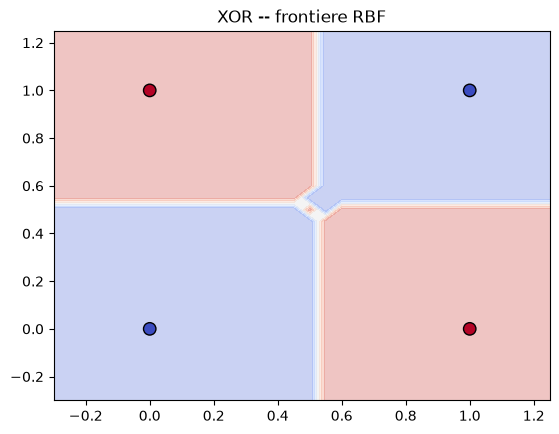

In [3]:
inputs = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
labels = [0, 1, 1, 0]

model = entrainer_rbf(inputs, labels, n_centres=4, gamma=2.0)
dessiner_frontiere(model, inputs, labels, "XOR -- frontiere RBF")
lib.destroy_rbf_model(model)

## 3. Cas non lineaire (cercle) + effet de gamma

Dataset synthetique : classe 0 = points pres du centre, classe 1 = points sur
exterieur.

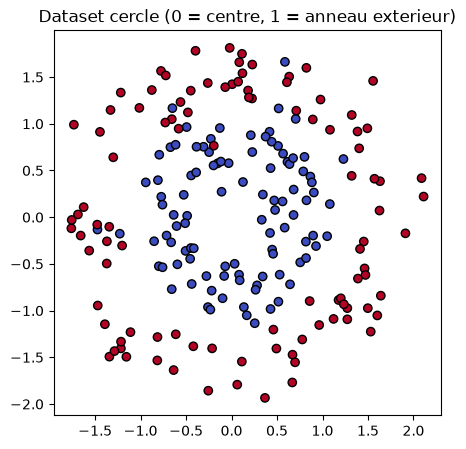

In [4]:
def generer_cercle(n=200, seed=42):
    rng = np.random.RandomState(seed)
    angles = rng.uniform(0, 2 * np.pi, n)

    n_int = n // 2
    n_ext = n - n_int
    rayons = np.concatenate([
        rng.normal(0.8, 0.25, n_int),   # classe 0 : pres du centre
        rng.normal(1.6, 0.25, n_ext),   # classe 1 : exterieur
    ])
    labels = np.concatenate([np.zeros(n_int, dtype=int), np.ones(n_ext, dtype=int)])

    X = np.stack([rayons * np.cos(angles), rayons * np.sin(angles)], axis=1)
    return X, labels


X_train_c, y_train_c = generer_cercle(n=200, seed=42)
X_test_c, y_test_c = generer_cercle(n=200, seed=123)

plt.figure(figsize=(5, 5))
plt.scatter(X_train_c[:, 0], X_train_c[:, 1], c=y_train_c, cmap="coolwarm", edgecolors="k")
plt.title("Dataset cercle (0 = centre, 1 = anneau exterieur)")
plt.show()

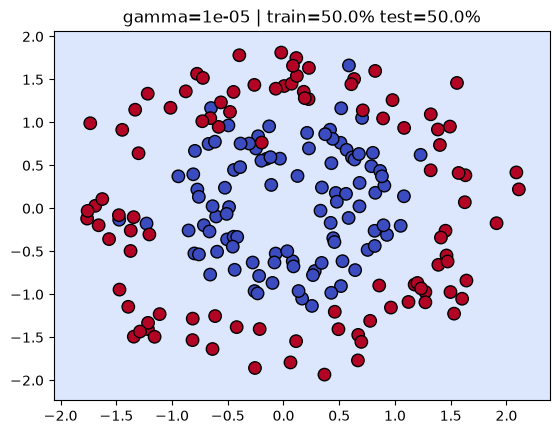

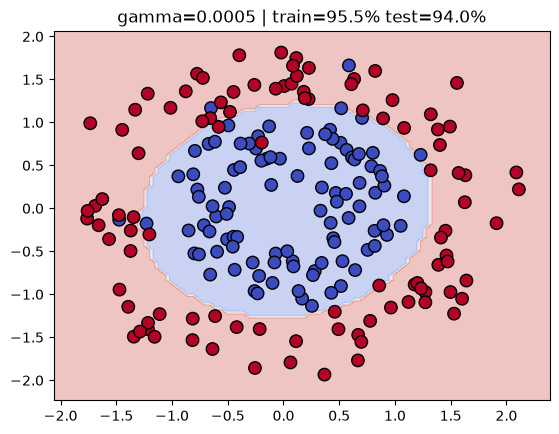

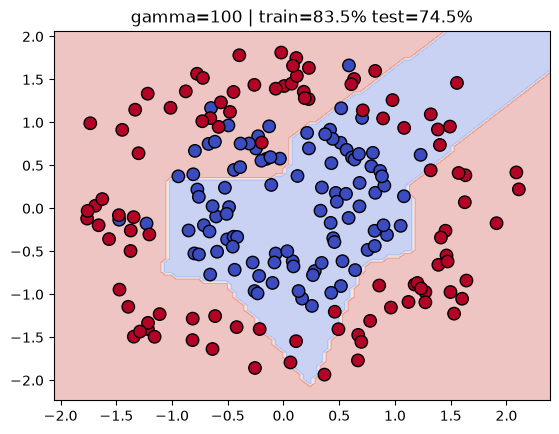

In [5]:
GAMMAS = [0.00001, 0.0005, 100]

for gamma in GAMMAS:
    model = entrainer_rbf(X_train_c, y_train_c, n_centres=10, gamma=gamma)
    train_acc = precision_rbf(model, X_train_c, y_train_c)
    test_acc = precision_rbf(model, X_test_c, y_test_c)

    titre = f"gamma={gamma} | train={train_acc:.1f}% test={test_acc:.1f}%"
    dessiner_frontiere(model, X_train_c, y_train_c, titre)

    lib.destroy_rbf_model(model)

### Analyse

- **gamma trop petit** (`0.00001`, bosses tres larges) : presque tous les
  points, proches ou lointains, activent les bosses de la meme facon ->
  le reseau ne discrimine presque rien -> **sous-apprentissage** (train et
  test pres du hasard, ~50 %).
  
- **gamma intermediaire** (`0.0005`) : les bosses ont la bonne largeur pour
  suivre la forme de l'anneau -> meilleur compromis (train ~96 %, test
  ~91 %).

- **gamma trop grand** (`100`) : les bosses deviennent etroites, le modele
  se met a coller aux particularites du train -> **sur-apprentissage**

## 4. Sauvegarde et chargement du modele (sans reentrainer)

In [6]:
inputs = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
labels = [0, 1, 1, 0]  # XOR

os.makedirs(os.path.join("..", "models"), exist_ok=True)
chemin = os.path.join("..", "models", "rbf_xor.txt")

model = entrainer_rbf(inputs, labels, n_centres=4, gamma=2.0)
lib.save_rbf_model(model, chemin.encode())
lib.destroy_rbf_model(model)

model_charge = lib.load_rbf_model(chemin.encode())
for x, y in zip(inputs, labels):
    print(f"  entree {x} | attendu {y} | predit (modele recharge) {predire_rbf(model_charge, x)}")
lib.destroy_rbf_model(model_charge)

  entree [0.0, 0.0] | attendu 0 | predit (modele recharge) 0
  entree [0.0, 1.0] | attendu 1 | predit (modele recharge) 1
  entree [1.0, 0.0] | attendu 1 | predit (modele recharge) 1
  entree [1.0, 1.0] | attendu 0 | predit (modele recharge) 0
